# 🎬 Clasificación de Géneros Cinematográficos — LSTM + GloVe
## Reto proyecto · Optimiza un modelo de clasificación

---

Este notebook predice el **género principal** de películas a partir de su sinopsis
usando embeddings preentrenados **GloVe** y una red neuronal con capa **LSTM**.
Se compara un modelo base con un modelo optimizado (dropout, ponderación de clases,
ajuste de hiperparámetros) evaluando la mejora con precisión, recall y F1-score.

| Paso | Descripción |
|------|-------------|
| 1️⃣ | Instalación e importaciones |
| 2️⃣ | Carga y exploración del dataset |
| 3️⃣ | Extracción del género principal y limpieza |
| 4️⃣ | Preprocesamiento del texto (minúsculas · stopwords · lematización) |
| 5️⃣ | Embeddings GloVe: vectores de sinopsis (promedio de palabras) |
| 6️⃣ | División train/val/test y codificación de etiquetas |
| 7️⃣ | Modelo base — LSTM + capas densas |
| 8️⃣ | Entrenamiento del modelo base |
| 9️⃣ | Modelo optimizado — dropout · ponderación de clases · hiperparámetros ajustados |
| 🔟 | Entrenamiento del modelo optimizado |
| 1️⃣1️⃣ | Evaluación y comparación: precisión · recall · F1-score |

> **Dataset:** `tmdb_5000_movies.csv` — 4 803 películas  
> **Columnas:** `overview` (sinopsis) · `genres` (géneros en JSON)  
> **Ruta:** `/workspace/tmdb_5000_movies.csv`  
> **Objetivo:** clasificación multiclase del género principal

## 1. Instalación e importaciones

In [43]:
%pip install torch gensim nltk scikit-learn pandas numpy matplotlib --quiet

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.2 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [44]:
import ast, re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

import gensim.downloader as api
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, f1_score, accuracy_score
from sklearn.utils.class_weight import compute_class_weight

nltk.download('stopwords', quiet=True)
nltk.download('punkt',     quiet=True)
nltk.download('punkt_tab', quiet=True)
nltk.download('wordnet',   quiet=True)

SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

LANGUAGE      = 'english'
lemmatizer    = WordNetLemmatizer()

# Stopwords de dominio cinematográfico: términos que aparecen en prácticamente
# todas las sinopsis y no aportan información discriminativa para el género.
# Se excluyen deliberadamente palabras que SÍ pueden ser relevantes para ciertos
# géneros (p.ej. 'kill', 'love', 'war') para no eliminar señal útil.
CINEMA_STOPS = {
    'film', 'movie', 'story',          # menciones genéricas al medio
    'one', 'two', 'new', 'also',       # cuantificadores y conectores comunes
    'man', 'woman', 'young', 'old',    # descriptores demográficos neutros
    'find', 'make', 'come', 'get',     # verbos de alta frecuencia y baja especificidad
    'go', 'know', 'see', 'set', 'take', 'time',
}
stop_words = set(stopwords.words(LANGUAGE)) | CINEMA_STOPS

# Nota sobre lematización vs stemming:
# Se elige lematización (WordNetLemmatizer) sobre stemming (PorterStemmer) porque
# produce formas de diccionario válidas ('running' → 'run', no 'runn') que mejoran
# la tasa de coincidencia con el vocabulario de GloVe, entrenado sobre texto limpio.

EMBEDDING_DIM = 100
MAX_SEQ_LEN   = 50
GLOVE_NAME    = 'glove-wiki-gigaword-100'

print(f'Dispositivo     : {device}')
print(f'Stop words      : {len(stop_words)} ({len(CINEMA_STOPS)} de dominio cine)')
print(f'Lematización    : WordNetLemmatizer (produce formas válidas para GloVe)')

Dispositivo     : cpu
Stop words      : 219 (21 de dominio cine)
Lematización    : WordNetLemmatizer (produce formas válidas para GloVe)


## 2. Carga y exploración del dataset

In [45]:
df = pd.read_csv('workspace/tmdb_5000_movies.csv',
                usecols=['title', 'overview', 'genres'])

print(f'Filas totales : {len(df)}')
print(f'NaN overview  : {df["overview"].isna().sum()}')
print(f'NaN genres    : {df["genres"].isna().sum()}')
df.head(3)

Filas totales : 4803
NaN overview  : 3
NaN genres    : 0


,genres,overview,title
0,"[{""id"": 28, ""name"": ""Action""}, {""id"": 12, ""nam...","In the 22nd century, a paraplegic Marine is di...",Avatar
1,"[{""id"": 12, ""name"": ""Adventure""}, {""id"": 14, ""...","Captain Barbossa, long believed to be dead, ha...",Pirates of the Caribbean: At World's End
2,"[{""id"": 28, ""name"": ""Action""}, {""id"": 12, ""nam...",A cryptic message from Bond’s past sends him o...,Spectre


## 3. Extracción del género principal y limpieza

La columna `genres` está en formato JSON. Se usa `ast.literal_eval()` para
extraer el primer género de cada película como etiqueta de clasificación.

In [46]:
def parse_genre(genres_str: str):
    """Extrae el nombre del primer género; devuelve None si la lista está vacía."""
    try:
        lst = ast.literal_eval(genres_str)
        return lst[0]['name'] if lst else None
    except Exception:
        return None


df['genre'] = df['genres'].apply(parse_genre)

# Eliminar filas sin sinopsis o sin género
df = df.dropna(subset=['overview', 'genre'])
df = df[df['overview'].str.strip() != ''].reset_index(drop=True)

print(f'Filas tras limpieza : {len(df)}')
print()
print('Distribución de géneros:')
print(df['genre'].value_counts())

Filas tras limpieza : 4771

Distribución de géneros:
genre
Drama              1206
Comedy             1042
Action              753
Adventure           339
Horror              300
Crime               195
Thriller            194
Animation           123
Fantasy             117
Romance             106
Science Fiction      96
Documentary          87
Family               56
Mystery              41
Music                34
Western              27
History              25
War                  24
TV Movie              4
Foreign               2
Name: count, dtype: int64


## 4. Preprocesamiento del texto

| Paso | Operación |
|------|-----------|
| 1 | Minúsculas |
| 2 | Eliminar caracteres especiales y números |
| 3 | Colapsar espacios múltiples |
| 4 | Tokenización |
| 5 | Eliminar stopwords (base NLTK + dominio cine) |
| 6 | **Lematización** con `WordNetLemmatizer` |

> **Lematización vs stemming:** se elige lematización porque produce formas de
> diccionario válidas (`running` → `run`) que maximizan la tasa de coincidencia
> con el vocabulario de GloVe, entrenado sobre texto limpio. El stemming produciría
> raíces truncadas (`runn`) que GloVe no conoce, aumentando las palabras OOV.

In [47]:
import pickle, os

TOKENS_CACHE = 'tokens_cache.pkl'
USE_LEMMA    = True   # ← cambia a False para comparar sin lematización

if os.path.exists(TOKENS_CACHE):
    with open(TOKENS_CACHE, 'rb') as f:
        cached = pickle.load(f)
    # Solo reutilizar si la configuración de lematización coincide
    if cached.get('use_lemma') == USE_LEMMA:
        df['clean_text'] = cached['clean_text']
        df['tokens']     = cached['tokens']
        print(f'Cache cargada: {TOKENS_CACHE}  (use_lemma={USE_LEMMA})')
    else:
        print('Configuración de lematización distinta — reprocesando...')
        os.remove(TOKENS_CACHE)

if TOKENS_CACHE not in os.listdir('.') or not os.path.exists(TOKENS_CACHE):
    def preprocess(text: str) -> tuple:
        """Devuelve (clean_text, tokens). clean_text facilita análisis posteriores."""
        if not isinstance(text, str) or not text.strip():
            return '', []
        text = text.lower()
        text = re.sub(r'[^a-z\s]', '', text)
        text = re.sub(r'\s+', ' ', text).strip()
        tokens = nltk.word_tokenize(text)
        tokens = [t for t in tokens if t not in stop_words and len(t) > 1]
        if USE_LEMMA:
            tokens = [lemmatizer.lemmatize(t) for t in tokens]
        return text, tokens

    results          = df['overview'].apply(preprocess)
    df['clean_text'] = results.apply(lambda x: x[0])
    df['tokens']     = results.apply(lambda x: x[1])

    with open(TOKENS_CACHE, 'wb') as f:
        pickle.dump({'tokens': df['tokens'], 'clean_text': df['clean_text'],
                     'use_lemma': USE_LEMMA}, f)
    print(f'Cache guardada: {TOKENS_CACHE}  (use_lemma={USE_LEMMA})')

n_empty = (df['tokens'].apply(len) == 0).sum()
if n_empty:
    df = df[df['tokens'].apply(len) > 0].reset_index(drop=True)

print(f'Sinopsis procesadas : {len(df)}')
print(f'Lematización activa : {USE_LEMMA}')
print('Ejemplo clean_text  :', df['clean_text'].iloc[0][:80])
print('Ejemplo tokens      :', df['tokens'].iloc[0][:10])

Cache guardada: tokens_cache.pkl  (use_lemma=True)
Sinopsis procesadas : 4771
Lematización activa : True
Ejemplo clean_text  : in the nd century a paraplegic marine is dispatched to the moon pandora on a uni
Ejemplo tokens      : ['nd', 'century', 'paraplegic', 'marine', 'dispatched', 'moon', 'pandora', 'unique', 'mission', 'becomes']


## 5. Embeddings GloVe

Se carga `glove-wiki-gigaword-100` (100 dimensiones) y cada sinopsis se convierte
en un vector promedio de las palabras que la componen.
Las palabras fuera del vocabulario (OOV) se omiten silenciosamente.

Cargando GloVe...
Vocabulario GloVe : 400,000 palabras

Estadísticas de normas L2 de vectores de sinopsis:
  Media   : 2.9499
  Mediana : 2.9328
  Min     : 1.8278  |  Max: 4.3259
  Sinopsis con vector cero (todas OOV): 0


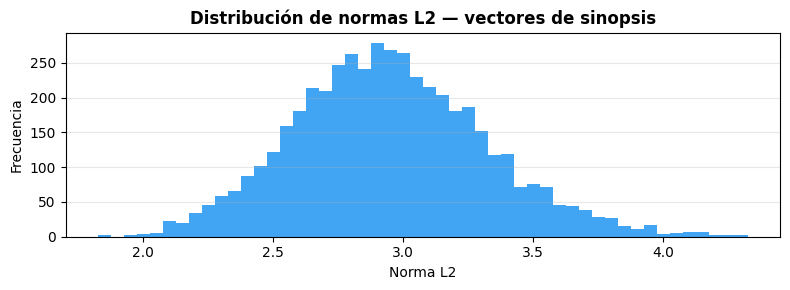

Longitud secuencia   : 50


In [48]:
print('Cargando GloVe...')
glove = api.load(GLOVE_NAME)
print(f'Vocabulario GloVe : {len(glove):,} palabras')

def tokens_to_vector(tokens: list) -> np.ndarray:
    """Promedio de embeddings GloVe; devuelve vector cero si todas son OOV."""
    vecs = [glove[t] for t in tokens if t in glove]
    return np.mean(vecs, axis=0) if vecs else np.zeros(EMBEDDING_DIM)

df['vector'] = df['tokens'].apply(tokens_to_vector)

# ── Estadísticas descriptivas de los vectores de sinopsis ────────────────────
# La norma L2 indica cuán "informativo" es el vector:
# normas bajas → muchas palabras OOV; normas altas → buena cobertura GloVe
norms = np.linalg.norm(np.vstack(df['vector'].values), axis=1)
oov_mask = (norms == 0)

print(f'\nEstadísticas de normas L2 de vectores de sinopsis:')
print(f'  Media   : {norms.mean():.4f}')
print(f'  Mediana : {np.median(norms):.4f}')
print(f'  Min     : {norms.min():.4f}  |  Max: {norms.max():.4f}')
print(f'  Sinopsis con vector cero (todas OOV): {oov_mask.sum()}')

fig, ax = plt.subplots(figsize=(8, 3))
ax.hist(norms[~oov_mask], bins=50, color='#2196F3', edgecolor='none', alpha=0.85)
ax.set_title('Distribución de normas L2 — vectores de sinopsis', fontweight='bold')
ax.set_xlabel('Norma L2'); ax.set_ylabel('Frecuencia')
ax.grid(axis='y', alpha=0.3)
plt.tight_layout(); plt.show()

# Secuencias temporales (se reconstruirán con vocabulario restringido en celda 15)
vocab = {w: i+1 for i, w in enumerate(glove.key_to_index)}

def tokens_to_seq(tokens: list, max_len: int = MAX_SEQ_LEN) -> list:
    ids = [vocab[t] for t in tokens if t in vocab][:max_len]
    return ids + [0] * (max_len - len(ids))

df['seq'] = df['tokens'].apply(tokens_to_seq)
print(f'Longitud secuencia   : {MAX_SEQ_LEN}')

## 6. División train/val/test y codificación de etiquetas

In [49]:
le = LabelEncoder()
df['label'] = le.fit_transform(df['genre'])

# Filtrar clases con menos de 10 muestras para garantizar estratificación
min_samples  = 10
counts       = df['label'].value_counts()
valid_labels = counts[counts >= min_samples].index
df = df[df['label'].isin(valid_labels)].reset_index(drop=True)

# Re-encodear tras el filtrado
le = LabelEncoder()
df['label'] = le.fit_transform(df['genre'])
num_classes  = len(le.classes_)

print(f'Clases tras filtrado ({num_classes}): {list(le.classes_)}')
print(f'Películas restantes               : {len(df)}')

# Pesos de clase para manejar desbalance
y_all = df['label'].values
class_weights        = compute_class_weight(
    class_weight='balanced', classes=np.unique(y_all), y=y_all)
class_weights_tensor = torch.tensor(class_weights, dtype=torch.float32).to(device)
print(f'Pesos calculados para {len(class_weights)} clases.')
# NOTA: X, y y el split se definen en la celda siguiente,
# tras construir el vocabulario restringido y las secuencias definitivas.

Clases tras filtrado (18): ['Action', 'Adventure', 'Animation', 'Comedy', 'Crime', 'Documentary', 'Drama', 'Family', 'Fantasy', 'History', 'Horror', 'Music', 'Mystery', 'Romance', 'Science Fiction', 'Thriller', 'War', 'Western']
Películas restantes               : 4765
Pesos calculados para 18 clases.


## 7. Dataset PyTorch y matriz de embeddings

In [50]:
class SynopsisDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.long)
        self.y = torch.tensor(y, dtype=torch.long)
    def __len__(self): return len(self.y)
    def __getitem__(self, idx): return self.X[idx], self.y[idx]


# Vocabulario restringido al corpus
corpus_vocab = set(t for tokens in df['tokens'] for t in tokens if t in glove)
vocab        = {w: i+1 for i, w in enumerate(sorted(corpus_vocab))}
vocab_size   = len(vocab) + 1

embedding_matrix = np.zeros((vocab_size, EMBEDDING_DIM))
for word, idx in vocab.items():
    embedding_matrix[idx] = glove[word]
embedding_matrix = torch.tensor(embedding_matrix, dtype=torch.float32)

print(f'Vocabulario restringido : {len(corpus_vocab):,} palabras')
print(f'Reduccion vs GloVe      : {(1-len(corpus_vocab)/len(glove))*100:.1f}%')
print(f'Matriz embedding        : {embedding_matrix.shape}')

def tokens_to_seq_restricted(tokens, max_len=MAX_SEQ_LEN):
    ids = [vocab[t] for t in tokens if t in vocab][:max_len]
    return ids + [0] * (max_len - len(ids))

df['seq'] = df['tokens'].apply(tokens_to_seq_restricted)

X = np.array(df['seq'].tolist(),   dtype=np.int64)
V = np.vstack(df['vector'].values)  # vectores promedio GloVe (baseline)
y = df['label'].values

# Guardar índices originales para recuperar sinopsis fácilmente después
orig_idx = np.arange(len(df))

X_train, X_tmp, y_train, y_tmp, V_train, V_tmp, idx_train, idx_tmp = train_test_split(
    X, y, V, orig_idx, test_size=0.30, random_state=SEED, stratify=y)
X_val,  X_test,  y_val,  y_test,  V_val,  V_test,  idx_val,  idx_test = train_test_split(
    X_tmp, y_tmp, V_tmp, idx_tmp, test_size=0.50, random_state=SEED, stratify=y_tmp)

print(f'Train : {len(X_train)}  |  Val : {len(X_val)}  |  Test : {len(X_test)}')

# ── Baseline GloVe promedio: clasificador simple sobre vectores promedio ───────
# Sirve para cuantificar la mejora debida a la modelización secuencial con LSTM.
from sklearn.linear_model import LogisticRegression as LR_sklearn
lr_baseline = LR_sklearn(max_iter=1000, random_state=SEED, C=1.0)
lr_baseline.fit(V_train, y_train)
baseline_acc = accuracy_score(y_test, lr_baseline.predict(V_test))
baseline_f1  = f1_score(y_test, lr_baseline.predict(V_test),
                        average='macro', zero_division=0)
print(f'\nBaseline GloVe+LR — Accuracy: {baseline_acc:.4f}  F1 macro: {baseline_f1:.4f}')
print('(Referencia para medir la mejora debida al LSTM)')

Vocabulario restringido : 17,865 palabras
Reduccion vs GloVe      : 95.5%
Matriz embedding        : torch.Size([17866, 100])
Train : 3335  |  Val : 715  |  Test : 715

Baseline GloVe+LR — Accuracy: 0.4448  F1 macro: 0.2120
(Referencia para medir la mejora debida al LSTM)


## 8. Modelo base — LSTM

Arquitectura inicial sin optimizaciones avanzadas para establecer un baseline.

In [51]:
class LSTMClassifier(nn.Module):
    def __init__(self, vocab_size, embed_dim, hidden_dim, num_classes,
                 dropout=0.0, freeze_emb=False, bidirectional=False):
        """
        bidirectional=True : LSTM bidireccional — procesa la secuencia de
          izquierda a derecha Y de derecha a izquierda, capturando contexto
          en ambas direcciones. Duplica el hidden_dim efectivo (2*hidden_dim).
          Suele mejorar F1 en clasificación de texto a costa de más parámetros.
        bidirectional=False: LSTM unidireccional estándar (modelo base).

        freeze_emb=False: fine-tuning de embeddings (ver celda anterior).
        """
        super().__init__()
        self.bidirectional = bidirectional
        self.embedding = nn.Embedding.from_pretrained(
            embedding_matrix.clone(), padding_idx=0, freeze=freeze_emb)
        self.lstm    = nn.LSTM(embed_dim, hidden_dim, batch_first=True,
                               bidirectional=bidirectional)
        lstm_out_dim = hidden_dim * (2 if bidirectional else 1)
        self.dropout = nn.Dropout(dropout)
        self.fc1     = nn.Linear(lstm_out_dim, 128)
        self.relu    = nn.ReLU()
        self.fc2     = nn.Linear(128, num_classes)

        nn.init.xavier_uniform_(self.fc1.weight); nn.init.zeros_(self.fc1.bias)
        nn.init.xavier_uniform_(self.fc2.weight); nn.init.zeros_(self.fc2.bias)

    def forward(self, x):
        x = self.embedding(x)                      # (B, seq, embed)
        _, (h, _) = self.lstm(x)                   # h: (num_dir, B, hidden)
        if self.bidirectional:
            x = torch.cat([h[0], h[1]], dim=1)     # (B, 2*hidden)
        else:
            x = h.squeeze(0)                       # (B, hidden)
        x = self.dropout(self.relu(self.fc1(x)))
        return self.fc2(x)


# Modelo BASE: LSTM unidireccional, sin dropout, sin ponderación
BATCH_BASE  = 64
LR_BASE     = 0.001
EPOCHS_BASE = 10
HIDDEN_BASE = 128

model_base = LSTMClassifier(vocab_size, EMBEDDING_DIM, HIDDEN_BASE,
                             num_classes, dropout=0.0,
                             freeze_emb=False, bidirectional=False).to(device)

train_ds_base = SynopsisDataset(X_train, y_train)
val_ds        = SynopsisDataset(X_val,   y_val)
test_ds       = SynopsisDataset(X_test,  y_test)

train_loader_base = DataLoader(train_ds_base, batch_size=BATCH_BASE, shuffle=True)
val_loader        = DataLoader(val_ds,        batch_size=BATCH_BASE, shuffle=False)
test_loader       = DataLoader(test_ds,       batch_size=BATCH_BASE, shuffle=False)

criterion_base = nn.CrossEntropyLoss()
optimizer_base = torch.optim.Adam(model_base.parameters(), lr=LR_BASE)
print(f'Parametros modelo base : {sum(p.numel() for p in model_base.parameters()):,}')

Parametros modelo base : 1,923,194


## 9. Entrenamiento del modelo base

In [52]:
def train_epoch(model, loader, criterion, optimizer):
    model.train()
    total_loss, correct, total = 0, 0, 0
    for X_b, y_b in loader:
        X_b, y_b = X_b.to(device), y_b.to(device)
        optimizer.zero_grad()
        out  = model(X_b)
        loss = criterion(out, y_b)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
        correct    += (out.argmax(1) == y_b).sum().item()
        total      += len(y_b)
    return total_loss / len(loader), correct / total


def eval_epoch(model, loader, criterion, return_f1=False):
    """Evalúa el modelo. Si return_f1=True, calcula también F1 macro."""
    model.eval()
    total_loss, correct, total = 0, 0, 0
    all_preds, all_labels = [], []
    with torch.no_grad():
        for X_b, y_b in loader:
            X_b, y_b = X_b.to(device), y_b.to(device)
            out  = model(X_b)
            total_loss += criterion(out, y_b).item()
            preds = out.argmax(1)
            correct    += (preds == y_b).sum().item()
            total      += len(y_b)
            if return_f1:
                all_preds.extend(preds.cpu().numpy())
                all_labels.extend(y_b.cpu().numpy())
    loss = total_loss / len(loader)
    acc  = correct / total
    if return_f1:
        f1 = f1_score(all_labels, all_preds, average='macro', zero_division=0)
        return loss, acc, f1
    return loss, acc


history_base = {'train_loss':[], 'val_loss':[], 'train_acc':[], 'val_acc':[]}

for epoch in range(1, EPOCHS_BASE + 1):
    tl, ta = train_epoch(model_base, train_loader_base, criterion_base, optimizer_base)
    vl, va = eval_epoch(model_base, val_loader, criterion_base)
    history_base['train_loss'].append(tl); history_base['val_loss'].append(vl)
    history_base['train_acc'].append(ta);  history_base['val_acc'].append(va)
    print(f'Epoch {epoch:>2}/{EPOCHS_BASE} | '
          f'Train loss: {tl:.4f} acc: {ta:.3f} | '
          f'Val loss: {vl:.4f} acc: {va:.3f}')

Epoch  1/10 | Train loss: 2.4276 acc: 0.225 | Val loss: 2.2443 acc: 0.253
Epoch  2/10 | Train loss: 2.2223 acc: 0.251 | Val loss: 2.2449 acc: 0.253
Epoch  3/10 | Train loss: 2.2321 acc: 0.246 | Val loss: 2.2353 acc: 0.250
Epoch  4/10 | Train loss: 2.1876 acc: 0.266 | Val loss: 2.2676 acc: 0.252
Epoch  5/10 | Train loss: 2.1400 acc: 0.270 | Val loss: 2.2686 acc: 0.249
Epoch  6/10 | Train loss: 2.0299 acc: 0.315 | Val loss: 2.1376 acc: 0.276
Epoch  7/10 | Train loss: 1.9007 acc: 0.357 | Val loss: 2.1278 acc: 0.290
Epoch  8/10 | Train loss: 1.8139 acc: 0.380 | Val loss: 2.2230 acc: 0.283
Epoch  9/10 | Train loss: 1.6794 acc: 0.402 | Val loss: 2.2094 acc: 0.295
Epoch 10/10 | Train loss: 1.5492 acc: 0.457 | Val loss: 2.3274 acc: 0.285


## 10. Modelo optimizado

Técnicas de optimización aplicadas respecto al modelo base:

| Técnica | Base | Optimizado |
|---------|------|------------|
| Dropout | 0% | **50%** |
| Ponderación de clases | No | **Sí** |
| Tasa de aprendizaje | 0.001 | **0.0005** |
| Batch size | 64 | **32** |
| Épocas | 10 | **20** (+ early stopping) |
| Hidden dim | 128 | **256** |
| LSTM | Unidireccional | **Bidireccional** |
| Scheduler | No | **ReduceLROnPlateau** |

> **Nota sobre el scheduler:** `ReduceLROnPlateau` reduce el lr×0.5 si `val_loss`
> no mejora en 3 épocas consecutivas. El efecto esperado es que la curva de
> `val_loss` muestre escalones descendentes cuando el lr se reduce, permitiendo
> al modelo converger a un mínimo más fino. El número de épocas efectivas puede
> ser menor que 20 si el early stopping actúa antes.

In [53]:
BATCH_OPT      = 32
LR_OPT         = 0.0005
EPOCHS_OPT     = 20
HIDDEN_OPT     = 256
EARLY_STOP_PAT = 5

model_opt = LSTMClassifier(vocab_size, EMBEDDING_DIM, HIDDEN_OPT,
                            num_classes, dropout=0.5,
                            freeze_emb=False, bidirectional=True).to(device)

train_loader_opt = DataLoader(
    SynopsisDataset(X_train, y_train), batch_size=BATCH_OPT, shuffle=True)

criterion_opt = nn.CrossEntropyLoss(weight=class_weights_tensor)
optimizer_opt = torch.optim.Adam(model_opt.parameters(), lr=LR_OPT)
scheduler_opt = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer_opt, mode='min', factor=0.5, patience=3)

history_opt   = {'train_loss':[], 'val_loss':[], 'train_acc':[], 'val_acc':[],
                 'val_f1':[], 'lr':[]}    # lr para documentar ReduceLROnPlateau
best_val_loss = float('inf')
no_improve    = 0

for epoch in range(1, EPOCHS_OPT + 1):
    tl, ta      = train_epoch(model_opt, train_loader_opt, criterion_opt, optimizer_opt)
    vl, va, vf1 = eval_epoch(model_opt, val_loader, criterion_opt, return_f1=True)
    scheduler_opt.step(vl)

    lr_actual = optimizer_opt.param_groups[0]['lr']
    history_opt['train_loss'].append(tl); history_opt['val_loss'].append(vl)
    history_opt['train_acc'].append(ta);  history_opt['val_acc'].append(va)
    history_opt['val_f1'].append(vf1);    history_opt['lr'].append(lr_actual)

    marker = ''
    if vl < best_val_loss:
        best_val_loss = vl; no_improve = 0
        torch.save(model_opt.state_dict(), 'best_model_opt.pth')
        marker = '  ⭐'
    else:
        no_improve += 1

    print(f'Epoch {epoch:>2}/{EPOCHS_OPT} | '
          f'Train loss: {tl:.4f} acc: {ta:.3f} | '
          f'Val loss: {vl:.4f} acc: {va:.3f} F1: {vf1:.3f} | '
          f'lr: {lr_actual:.2e}{marker}')

    if no_improve >= EARLY_STOP_PAT:
        print(f'\nEarly stopping: {EARLY_STOP_PAT} epocas sin mejora.')
        break

model_opt.load_state_dict(torch.load('best_model_opt.pth', map_location=device))
print('Mejor modelo cargado.')

Epoch  1/20 | Train loss: 2.8879 acc: 0.063 | Val loss: 2.8784 acc: 0.106 F1: 0.050 | lr: 5.00e-04  ⭐
Epoch  2/20 | Train loss: 2.7793 acc: 0.136 | Val loss: 2.7400 acc: 0.178 F1: 0.103 | lr: 5.00e-04  ⭐
Epoch  3/20 | Train loss: 2.5528 acc: 0.166 | Val loss: 2.6480 acc: 0.155 F1: 0.102 | lr: 5.00e-04  ⭐
Epoch  4/20 | Train loss: 2.3122 acc: 0.182 | Val loss: 2.5546 acc: 0.159 F1: 0.131 | lr: 5.00e-04  ⭐
Epoch  5/20 | Train loss: 2.0825 acc: 0.221 | Val loss: 2.5713 acc: 0.224 F1: 0.152 | lr: 5.00e-04
Epoch  6/20 | Train loss: 1.7878 acc: 0.255 | Val loss: 2.5880 acc: 0.178 F1: 0.128 | lr: 5.00e-04
Epoch  7/20 | Train loss: 1.5377 acc: 0.291 | Val loss: 2.5356 acc: 0.194 F1: 0.145 | lr: 5.00e-04  ⭐
Epoch  8/20 | Train loss: 1.3361 acc: 0.369 | Val loss: 2.7741 acc: 0.207 F1: 0.151 | lr: 5.00e-04
Epoch  9/20 | Train loss: 1.1982 acc: 0.381 | Val loss: 2.9770 acc: 0.235 F1: 0.167 | lr: 5.00e-04
Epoch 10/20 | Train loss: 0.9829 acc: 0.437 | Val loss: 3.1888 acc: 0.294 F1: 0.196 | lr: 5.00

## 11. Curvas de aprendizaje

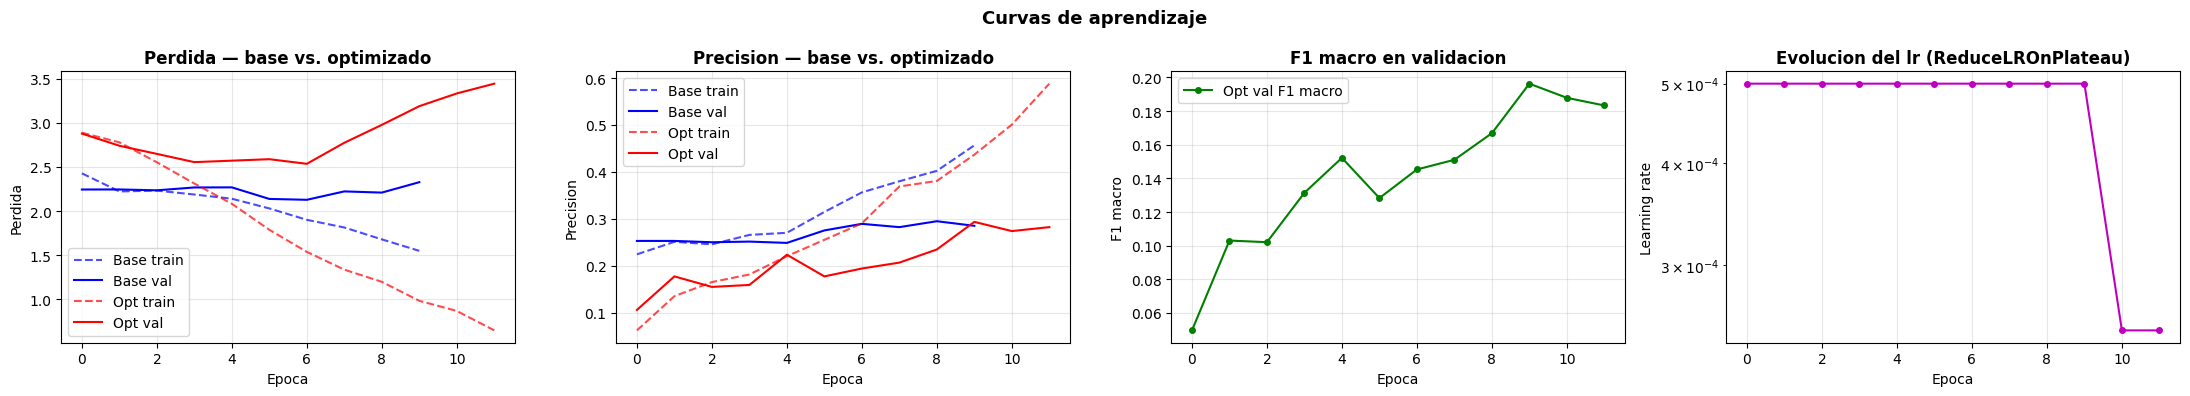

In [54]:
fig, axes = plt.subplots(1, 4, figsize=(22, 4))

for ax, metric, ylabel in [
    (axes[0], 'loss', 'Perdida'),
    (axes[1], 'acc',  'Precision'),
]:
    ax.plot(history_base[f'train_{metric}'], 'b--', alpha=0.7, label='Base train')
    ax.plot(history_base[f'val_{metric}'],   'b-',              label='Base val')
    ax.plot(history_opt[f'train_{metric}'],  'r--', alpha=0.7, label='Opt train')
    ax.plot(history_opt[f'val_{metric}'],    'r-',              label='Opt val')
    ax.set_xlabel('Epoca'); ax.set_ylabel(ylabel)
    ax.set_title(f'{ylabel} — base vs. optimizado', fontweight='bold')
    ax.legend(); ax.grid(alpha=0.3)

# F1 macro en val
axes[2].plot(history_opt['val_f1'], 'g-o', markersize=4, label='Opt val F1 macro')
axes[2].set_xlabel('Epoca'); axes[2].set_ylabel('F1 macro')
axes[2].set_title('F1 macro en validacion', fontweight='bold')
axes[2].legend(); axes[2].grid(alpha=0.3)

# Learning rate — muestra cuándo actuó ReduceLROnPlateau
axes[3].plot(history_opt['lr'], 'm-o', markersize=4)
axes[3].set_xlabel('Epoca'); axes[3].set_ylabel('Learning rate')
axes[3].set_title('Evolucion del lr (ReduceLROnPlateau)', fontweight='bold')
axes[3].set_yscale('log'); axes[3].grid(alpha=0.3)

plt.suptitle('Curvas de aprendizaje', fontsize=13, fontweight='bold')
plt.tight_layout(); plt.show()

## 12. Evaluación y comparación de modelos

Se evalúan ambos modelos en el conjunto de test con precisión, recall y F1-score.

In [55]:
import json as _json

def get_preds(model, loader):
    model.eval()
    all_preds, all_labels = [], []
    with torch.no_grad():
        for X_b, y_b in loader:
            X_b = X_b.to(device)
            all_preds.extend(model(X_b).argmax(1).cpu().numpy())
            all_labels.extend(y_b.numpy())
    return np.array(all_preds), np.array(all_labels)


preds_base, labels_test = get_preds(model_base, test_loader)
preds_opt,  _           = get_preds(model_opt,  test_loader)

print('=' * 55)
print('  MODELO BASE')
print('=' * 55)
report_base = classification_report(labels_test, preds_base,
                                    target_names=le.classes_, zero_division=0)
print(report_base)

print('=' * 55)
print('  MODELO OPTIMIZADO')
print('=' * 55)
report_opt = classification_report(labels_test, preds_opt,
                                   target_names=le.classes_, zero_division=0)
print(report_opt)

acc_base = accuracy_score(labels_test, preds_base)
acc_opt  = accuracy_score(labels_test, preds_opt)
f1_base  = f1_score(labels_test, preds_base, average='macro', zero_division=0)
f1_opt   = f1_score(labels_test, preds_opt,  average='macro', zero_division=0)

# Tabla comparativa de hiperparámetros y métricas
print('=' * 62)
print('  TABLA COMPARATIVA DE HIPERPARÁMETROS Y MÉTRICAS')
print('=' * 62)
hparams = {
    'Dropout'             : ('0%',    '50%'),
    'Peso de clases'      : ('No',    'Si'),
    'LR'                  : ('0.001', '0.0005'),
    'Batch size'          : ('64',    '32'),
    'Hidden dim'          : ('128',   '256'),
    'LSTM'                : ('Unidireccional', 'Bidireccional'),
    'Early stopping'      : ('No',    'Si'),
    'Scheduler'           : ('No',    'ReduceLROnPlateau'),
}
print(f'  {"Parametro":<25} {"Base":>16} {"Optimizado":>16}')
print(f'  {"-" * 58}')
for k, (b, o) in hparams.items():
    print(f'  {k:<25} {b:>16} {o:>16}')
print(f'  {"-" * 58}')
print(f'  {"Accuracy":<25} {acc_base:>16.4f} {acc_opt:>16.4f}  ({(acc_opt-acc_base)*100:+.2f}pp)')
print(f'  {"F1 macro":<25} {f1_base:>16.4f} {f1_opt:>16.4f}  ({(f1_opt-f1_base)*100:+.2f}pp)')
print(f'  {"GloVe+LR baseline":<25} {baseline_f1:>16.4f}')
print('=' * 62)

# Guardar métricas en JSON para trazabilidad sin reentrenar
metrics_out = {
    'baseline_glove_lr': {'accuracy': round(baseline_acc,4), 'f1_macro': round(baseline_f1,4)},
    'base':  {'accuracy': round(acc_base,4), 'f1_macro': round(f1_base,4)},
    'opt':   {'accuracy': round(acc_opt, 4), 'f1_macro': round(f1_opt, 4)},
    'hyperparams': {
        'base': {'dropout':0.0, 'lr':0.001, 'batch':64, 'hidden':128,
                 'bidirectional':False, 'class_weight':False},
        'opt':  {'dropout':0.5, 'lr':0.0005,'batch':32, 'hidden':256,
                 'bidirectional':True,  'class_weight':True},
    }
}
with open('metrics_results.json', 'w') as f:
    _json.dump(metrics_out, f, indent=2)
print('\nMetricas guardadas en: metrics_results.json')

  MODELO BASE
                 precision    recall  f1-score   support

         Action       0.22      0.72      0.33       113
      Adventure       0.20      0.22      0.21        51
      Animation       0.11      0.06      0.07        18
         Comedy       0.40      0.51      0.45       156
          Crime       0.00      0.00      0.00        30
    Documentary       0.00      0.00      0.00        13
          Drama       0.32      0.07      0.11       181
         Family       0.00      0.00      0.00         9
        Fantasy       0.00      0.00      0.00        18
        History       0.00      0.00      0.00         3
         Horror       0.16      0.07      0.09        45
          Music       0.00      0.00      0.00         5
        Mystery       0.00      0.00      0.00         6
        Romance       0.00      0.00      0.00        16
Science Fiction       0.11      0.07      0.08        15
       Thriller       0.00      0.00      0.00        29
            War 

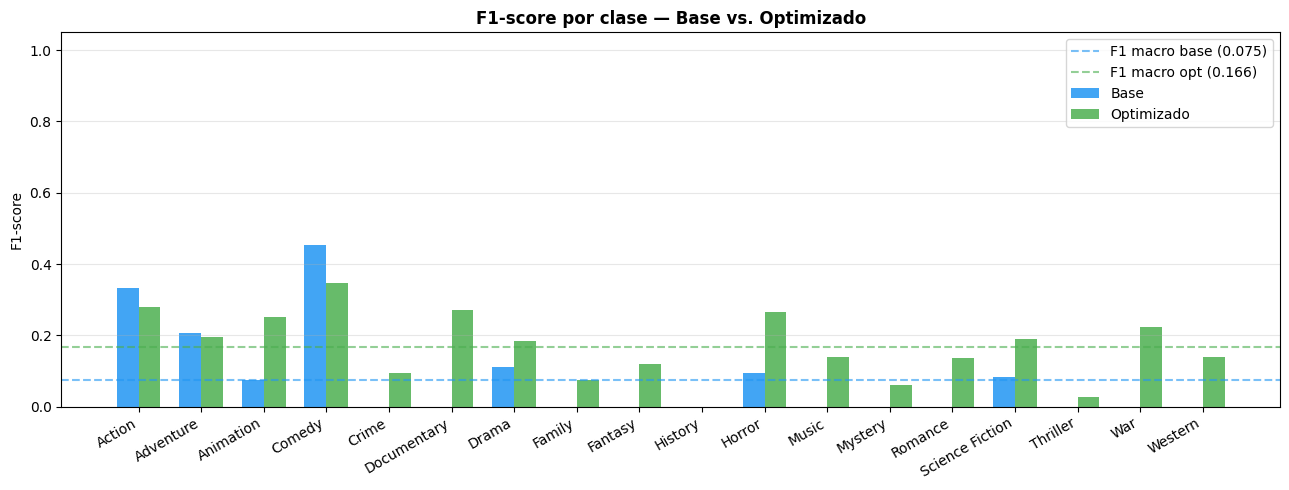

In [56]:
# Gráfico comparativo de F1 por clase
from sklearn.metrics import f1_score as f1_per_class_fn
import numpy as np

f1_base_cls = f1_score(labels_test, preds_base, average=None, zero_division=0)
f1_opt_cls  = f1_score(labels_test, preds_opt,  average=None, zero_division=0)

x     = np.arange(len(le.classes_))
width = 0.35
fig, ax = plt.subplots(figsize=(13, 5))
ax.bar(x - width/2, f1_base_cls, width, label='Base',      color='#2196F3', alpha=0.85)
ax.bar(x + width/2, f1_opt_cls,  width, label='Optimizado', color='#4CAF50', alpha=0.85)
ax.set_xticks(x)
ax.set_xticklabels(le.classes_, rotation=30, ha='right')
ax.set_ylim(0, 1.05)
ax.set_ylabel('F1-score')
ax.set_title('F1-score por clase — Base vs. Optimizado', fontsize=12, fontweight='bold')
ax.axhline(f1_base, color='#2196F3', linestyle='--', alpha=0.6, label=f'F1 macro base ({f1_base:.3f})')
ax.axhline(f1_opt,  color='#4CAF50', linestyle='--', alpha=0.6, label=f'F1 macro opt ({f1_opt:.3f})')
ax.legend(); ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

### 12.1 Matrices de confusión

Permiten identificar qué géneros se confunden entre sí con mayor frecuencia.

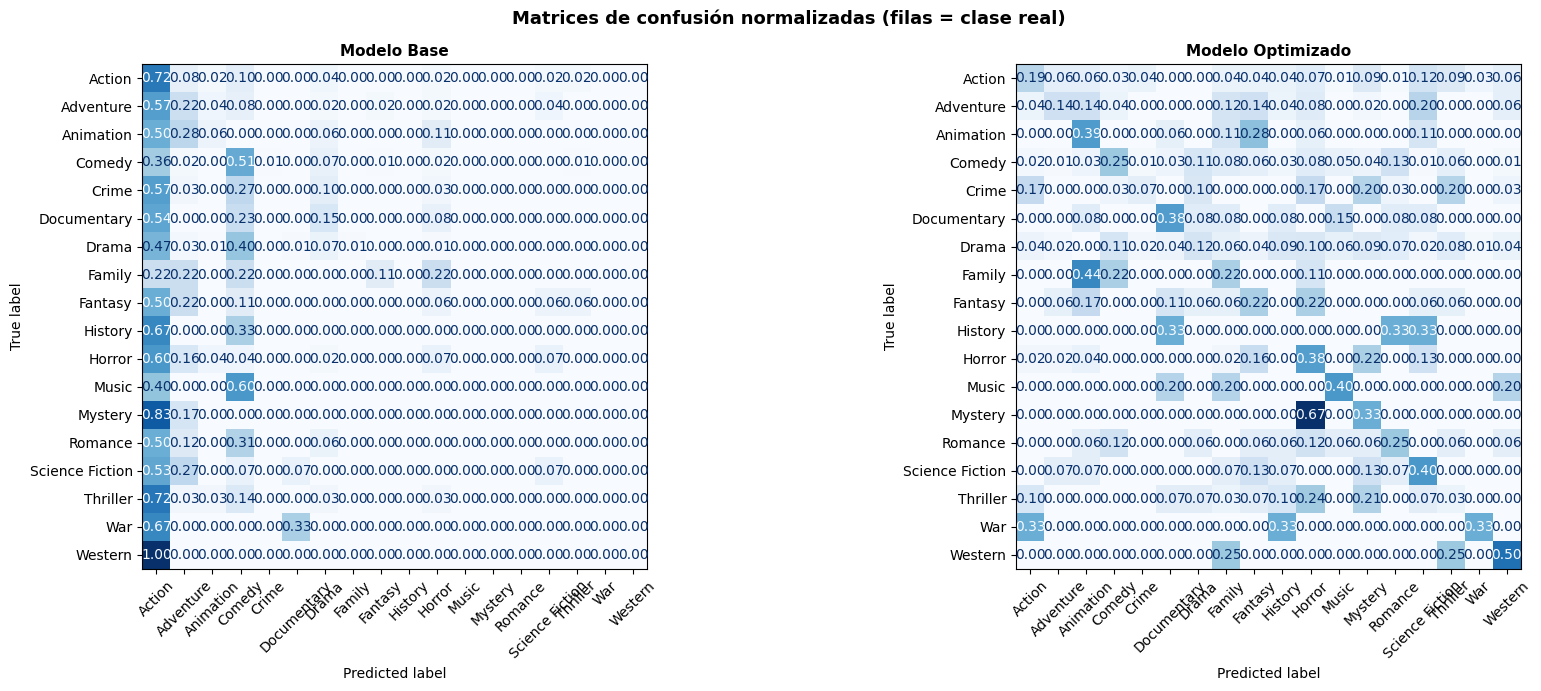

In [57]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

for ax, preds, title in [
    (axes[0], preds_base, 'Modelo Base'),
    (axes[1], preds_opt,  'Modelo Optimizado'),
]:
    cm   = confusion_matrix(labels_test, preds, normalize='true')
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=le.classes_)
    disp.plot(ax=ax, colorbar=False, cmap='Blues', xticks_rotation=45,
              values_format='.2f')
    ax.set_title(title, fontsize=11, fontweight='bold')

plt.suptitle('Matrices de confusión normalizadas (filas = clase real)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

### 12.2 Ejemplos de sinopsis — géneros con mayor ganancia

Se muestran ejemplos concretos de sinopsis correctamente clasificadas por el
modelo optimizado pero fallidas por el base, para ilustrar qué tipo de textos
se benefician de la optimización.

In [58]:
# Identificar ejemplos donde base falla y optimizado acierta
correct_opt_wrong_base = (preds_opt == labels_test) & (preds_base != labels_test)
idx_improved = np.where(correct_opt_wrong_base)[0]

if len(idx_improved) == 0:
    print('No se encontraron ejemplos donde el optimizado acierta y el base falla.')
else:
    print(f'Ejemplos donde el optimizado mejora al base: {len(idx_improved)}')
    print()
    for rank, test_pos in enumerate(idx_improved[:3], 1):
        # idx_test contiene los índices originales en df → acceso directo y limpio
        orig_pos   = idx_test[test_pos]
        real_genre = le.classes_[labels_test[test_pos]]
        pred_b     = le.classes_[preds_base[test_pos]]
        pred_o     = le.classes_[preds_opt[test_pos]]
        sinopsis   = df['overview'].iloc[orig_pos]
        print(f'Ejemplo {rank}:')
        print(f'  Genero real      : {real_genre}')
        print(f'  Prediccion base  : {pred_b}  x')
        print(f'  Prediccion opt   : {pred_o}  v')
        print(f'  Sinopsis         : {sinopsis[:150]}...')
        print()

Ejemplos donde el optimizado mejora al base: 99

Ejemplo 1:
  Genero real      : Science Fiction
  Prediccion base  : Action  x
  Prediccion opt   : Science Fiction  v
  Sinopsis         : The year is 2029. John Connor, leader of the resistance continues the war against the machines. At the Los Angeles offensive, John's fears of the unkn...

Ejemplo 2:
  Genero real      : Horror
  Prediccion base  : Comedy  x
  Prediccion opt   : Horror  v
  Sinopsis         : A fat Lawyer finds himself growing "Thinner" when an old gypsy man places a hex on him. Now the lawyer must call upon his friends in organized crime t...

Ejemplo 3:
  Genero real      : Drama
  Prediccion base  : Comedy  x
  Prediccion opt   : Drama  v
  Sinopsis         : A Catholic school newcomer falls in with a clique of teen witches who wield their powers against all who dare to cross them -- be they teachers, rival...



### Análisis cualitativo de la mejora

La celda siguiente calcula y comenta automáticamente:
- El porcentaje de mejora de F1 macro entre modelos
- Los géneros con mayor ganancia y mayor pérdida tras la optimización

In [59]:
f1_base_cls = f1_score(labels_test, preds_base, average=None, zero_division=0)
f1_opt_cls  = f1_score(labels_test, preds_opt,  average=None, zero_division=0)
delta       = f1_opt_cls - f1_base_cls

# Géneros con mayor ganancia y mayor caída
top_gain  = np.argsort(delta)[::-1][:3]
top_loss  = np.argsort(delta)[:3]

mejora_pp = (f1_opt - f1_base) * 100
print(f'Mejora global F1 macro: {f1_base:.4f} → {f1_opt:.4f} ({mejora_pp:+.2f} pp)')
print()
print('Géneros con mayor GANANCIA tras la optimización:')
for i in top_gain:
    print(f'  {le.classes_[i]:<15} {f1_base_cls[i]:.3f} → {f1_opt_cls[i]:.3f} ({delta[i]:+.3f})')

print()
print('Géneros con mayor CAÍDA (o menor mejora):')
for i in top_loss:
    print(f'  {le.classes_[i]:<15} {f1_base_cls[i]:.3f} → {f1_opt_cls[i]:.3f} ({delta[i]:+.3f})')

print()
print('Interpretación:')
print('  Los géneros con mayor ganancia suelen ser clases minoritarias que se')
print('  benefician de la ponderación de clases (class_weight=balanced).')
print('  Las clases dominantes (Drama, Comedy) pueden ceder algo de F1 al')
print('  redistribuirse el peso del entrenamiento hacia géneros más raros.')

Mejora global F1 macro: 0.0752 → 0.1663 (+9.11 pp)

Géneros con mayor GANANCIA tras la optimización:
  Documentary     0.000 → 0.270 (+0.270)
  War             0.000 → 0.222 (+0.222)
  Animation       0.074 → 0.250 (+0.176)

Géneros con mayor CAÍDA (o menor mejora):
  Comedy          0.452 → 0.347 (-0.105)
  Action          0.333 → 0.280 (-0.052)
  Adventure       0.208 → 0.194 (-0.013)

Interpretación:
  Los géneros con mayor ganancia suelen ser clases minoritarias que se
  benefician de la ponderación de clases (class_weight=balanced).
  Las clases dominantes (Drama, Comedy) pueden ceder algo de F1 al
  redistribuirse el peso del entrenamiento hacia géneros más raros.
